# Logistička regresija

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score, precision_recall_curve

In [ ]:
# Učitavanje skupa podataka
df_log = pd.read_csv('/content/heart_failure_clinical_records_dataset.csv')

In [ ]:
df_log['DEATH_EVENT'].value_counts()

,count
DEATH_EVENT,
0,203
1,96


In [ ]:
# Razdvajanje prediktornih varijabli i ciljne varijable
X = df_log.drop(['DEATH_EVENT'], axis=1)
Y = df_log['DEATH_EVENT']

In [ ]:
# Podjela na skupove za treniranje i testiranje na slučajan način
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)

In [ ]:
# Identifikacija numeričkih varijabli
numerical_features = X_train.select_dtypes(include=np.number).columns

# Skaliranje
scaler = StandardScaler()

X_train_scale = X_train.copy()
X_test_scale = X_test.copy()

X_train_scale[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scale[numerical_features] = scaler.transform(X_test[numerical_features])

In [ ]:
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train_scale, Y_train)

LogisticRegression(random_state=42)

In [ ]:
# Ispis koeficijenata logističke regresije uz ispis svake varijable
feature_names = X_train_scale.columns
coefficients = log_reg_model.coef_[0]

for feature, coef in zip(feature_names, coefficients):
    print(f"Varijabla: {feature}, Koeficijent: {coef}")

print("\nPresjek (intercept):", log_reg_model.intercept_[0])

Varijabla: age, Koeficijent: 0.2655765745818987
Varijabla: anaemia, Koeficijent: 0.17549375888031216
Varijabla: creatinine_phosphokinase, Koeficijent: 0.3096100430799533
Varijabla: diabetes, Koeficijent: 0.18299287410982118
Varijabla: ejection_fraction, Koeficijent: -0.8523256077467494
Varijabla: high_blood_pressure, Koeficijent: -0.0599191364067585
Varijabla: platelets, Koeficijent: -0.08555445206194383
Varijabla: serum_creatinine, Koeficijent: 0.9108716089917892
Varijabla: serum_sodium, Koeficijent: -0.11956390882419313
Varijabla: sex, Koeficijent: -0.08568783745457292
Varijabla: smoking, Koeficijent: 0.12406730903234911
Varijabla: time, Koeficijent: -1.5472090779594734

Presjek (intercept): -1.2756987644444604


In [ ]:
# Ispis exp(koeficijenata) logističke regresije uz ispis svake varijable
feature_names = X_train_scale.columns
coefficients = log_reg_model.coef_[0]

for feature, coef in zip(feature_names, coefficients):
    print(f"Varijabla: {feature}, exp(Koeficijent): {np.exp(coef)}")

print("\nPresjek (intercept):", np.exp(log_reg_model.intercept_[0]))

Varijabla: age, exp(Koeficijent): 1.3041827176450627
Varijabla: anaemia, exp(Koeficijent): 1.191834550245974
Varijabla: creatinine_phosphokinase, exp(Koeficijent): 1.362893540726057
Varijabla: diabetes, exp(Koeficijent): 1.2008058512397213
Varijabla: ejection_fraction, exp(Koeficijent): 0.4264220874028732
Varijabla: high_blood_pressure, exp(Koeficijent): 0.9418406911275665
Varijabla: platelets, exp(Koeficijent): 0.9180031545285471
Varijabla: serum_creatinine, exp(Koeficijent): 2.4864888351903405
Varijabla: serum_sodium, exp(Koeficijent): 0.8873072992407881
Varijabla: sex, exp(Koeficijent): 0.9178807144833838
Varijabla: smoking, exp(Koeficijent): 1.1320920684564157
Varijabla: time, exp(Koeficijent): 0.21284116877032938

Presjek (intercept): 0.2792357799993699


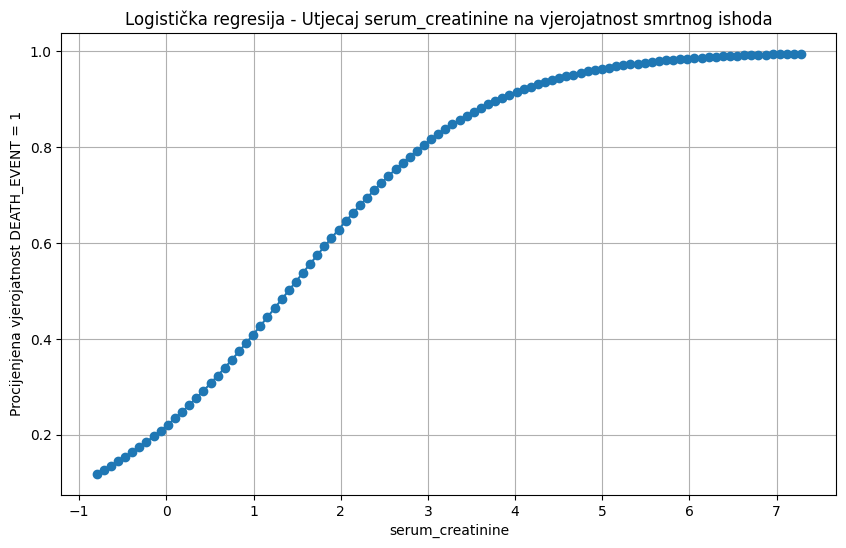

In [ ]:
# Generiramo raspon vrijednosti za 'serum_creatinine' - 100 točaka između min i max skalirane vrijednosti u skupu za treniranje
creatinine_values = np.linspace(X_train_scale['serum_creatinine'].min(),
                                X_train_scale['serum_creatinine'].max(), 100)

# Priprema predloška s prosjecima svih varijabli
temp_df_template_row = pd.DataFrame(X_train_scale.mean()).T

# Dupliciramo red 100 puta da bismo imali tablicu za sve točke
temp_df = pd.concat([temp_df_template_row] * 100, ignore_index=True)

# Ubacujemo vrijednosti serum_creatinine u predložak
temp_df['serum_creatinine'] = creatinine_values

# Provjeravamo da je redoslijed varijabli isti kao u skupu za treniranje
temp_df = temp_df[log_reg_model.feature_names_in_]

# Predikcija vjerojatnosti klase 1 (DEATH_EVENT = 1)
predicted_probabilities = log_reg_model.predict_proba(temp_df)[:, 1]

# Grafički prikaz
plt.figure(figsize=(10, 6))
plt.plot(creatinine_values, predicted_probabilities, marker='o', linestyle='-')
plt.xlabel('serum_creatinine')
plt.ylabel('Procijenjena vjerojatnost DEATH_EVENT = 1')
plt.title('Logistička regresija - Utjecaj serum_creatinine na vjerojatnost smrtnog ishoda')
plt.grid(True)
plt.show()


In [ ]:
# predikcija vjerojatnosti na skupu za treniranje
log_reg_model.predict_proba(X_train_scale)

array([[9.81480451e-01, 1.85195492e-02],
       [9.54209846e-01, 4.57901544e-02],
       [7.84668165e-01, 2.15331835e-01],
       [8.45615162e-01, 1.54384838e-01],
       [9.92288327e-01, 7.71167288e-03],
       [7.36727333e-01, 2.63272667e-01],
       [5.86836347e-01, 4.13163653e-01],
       [8.71587832e-02, 9.12841217e-01],
       [9.56267507e-01, 4.37324932e-02],
       [2.39710231e-01, 7.60289769e-01],
       [9.90544802e-01, 9.45519798e-03],
       [9.30235246e-01, 6.97647537e-02],
       [7.96365561e-01, 2.03634439e-01],
       [8.89894202e-01, 1.10105798e-01],
       [6.53903998e-01, 3.46096002e-01],
       [7.52919667e-02, 9.24708033e-01],
       [9.76203097e-01, 2.37969030e-02],
       [9.10482157e-01, 8.95178431e-02],
       [1.03584257e-01, 8.96415743e-01],
       [9.39880400e-01, 6.01196002e-02],
       [7.01393315e-02, 9.29860669e-01],
       [9.90335510e-01, 9.66449043e-03],
       [5.57349455e-01, 4.42650545e-01],
       [3.33426981e-01, 6.66573019e-01],
       [6.818389

In [ ]:
# 2. način dobivanja modela logističke regresije

logit_model = sm.Logit(Y_train, X_train_scale)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.447830
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            DEATH_EVENT   No. Observations:                  209
Model:                          Logit   Df Residuals:                      197
Method:                           MLE   Df Model:                           11
Date:                Sun, 11 Jan 2026   Pseudo R-squ.:                  0.2861
Time:                        08:28:52   Log-Likelihood:                -93.597
converged:                       True   LL-Null:                       -131.11
Covariance Type:            nonrobust   LLR p-value:                 1.344e-11
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
age                          0.2248      0.215      1.045      0.296      -0.197

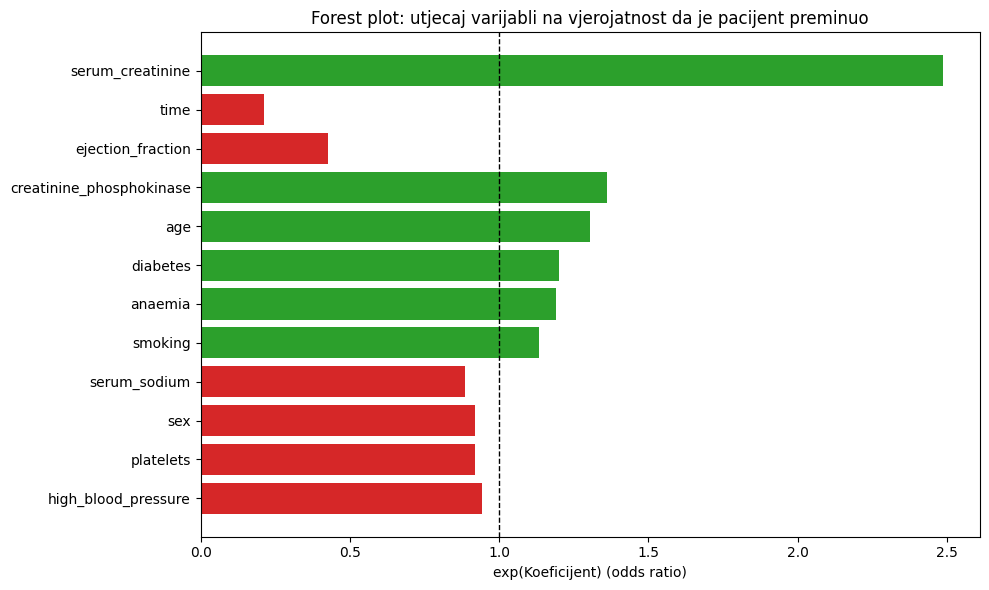

In [ ]:
# odabir varijabli i koeficijenata logističke regresije
feature_names = X_train_scale.columns
coefficients = log_reg_model.coef_[0]

# izračun exp(koef) = odds ratio
exp_coef = np.exp(coefficients)

# pretvaranje u DataFrame
df = pd.DataFrame({
    "Varijabla": feature_names,
    "Koeficijent": coefficients,
    "exp(Koeficijent)": exp_coef
})

# sortiranje po snazi učinka
df["Učinak"] = abs(df["exp(Koeficijent)"] - 1)
df = df.sort_values("Učinak", ascending=True)

# crtanje grafa
plt.figure(figsize=(10, 6))
colors = ["#d62728" if x < 1 else "#2ca02c" for x in df["exp(Koeficijent)"]]

plt.barh(df["Varijabla"], df["exp(Koeficijent)"], color=colors)
plt.axvline(x=1, color='black', linestyle='--', linewidth=1)
plt.xlabel("exp(Koeficijent) (odds ratio)")
plt.title("Forest plot: utjecaj varijabli na vjerojatnost da je pacijent preminuo")
plt.tight_layout()
plt.show()

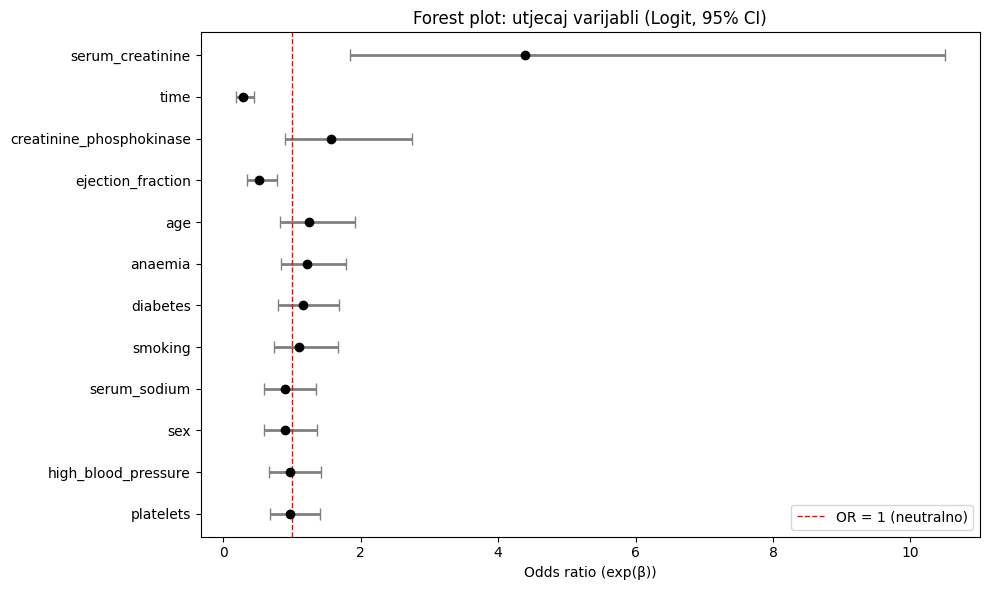

,Varijabla,OR,OR_low,OR_high,p_value
11,time,0.285050,0.184247,0.441003,1.730002e-08
7,serum_creatinine,4.392073,1.837596,10.497579,8.728209e-04
4,ejection_fraction,0.524153,0.350392,0.784083,1.668051e-03
2,creatinine_phosphokinase,1.572257,0.898769,2.750420,1.127589e-01
0,age,1.252094,0.821210,1.909060,2.961764e-01
1,anaemia,1.221441,0.838492,1.779287,2.973211e-01
3,diabetes,1.158015,0.797389,1.681737,4.409213e-01
8,serum_sodium,0.894749,0.592341,1.351546,5.971769e-01
9,sex,0.899717,0.591213,1.369204,6.218328e-01
10,smoking,1.106783,0.731727,1.674079,6.308383e-01


In [ ]:
# 1) Koeficijenti, p-vrijednosti i 95% CI iz modela log. regresije
params = result.params                      # β koeficijenti
conf = result.conf_int()                    # 95% CI u log-odds skali (DataFrame sa 0=lower, 1=upper)
pvals = result.pvalues                      # p-vrijednosti

# 2) Prevedi u odds ratio (exp) i CI u OR skali
or_ = np.exp(params)
or_low = np.exp(conf[0])
or_high = np.exp(conf[1])

# 3) Složi tablicu
df = pd.DataFrame({
    "Varijabla": params.index,
    "coef": params.values,
    "p_value": pvals.values,
    "OR": or_.values,
    "OR_low": or_low.values,
    "OR_high": or_high.values
})

# Makni intercept da ne smeta na grafu
df = df[df["Varijabla"].str.lower().ne("const") & df["Varijabla"].str.lower().ne("intercept")]

# 4) Sortiraj po veličini efekta (udaljenost od 1) ili po p-vrijednosti
df["effect_strength"] = (df["OR"] - 1).abs()
df = df.sort_values("effect_strength", ascending=True)   # ili: df.sort_values("p_value")

# 5) Crtanje forest plota
plt.figure(figsize=(10, 6))
# errorbar treba polu-širine CI (OR - OR_low, OR_high - OR)
xerr = np.vstack([df["OR"] - df["OR_low"], df["OR_high"] - df["OR"]])

plt.errorbar(
    x=df["OR"], y=df["Varijabla"],
    xerr=xerr, fmt='o', color='black',
    ecolor='gray', elinewidth=2, capsize=4
)

# Neutralna linija na OR=1
plt.axvline(x=1, color='red', linestyle='--', linewidth=1, label='OR = 1 (neutralno)')

plt.xlabel("Odds ratio (exp(β))")
plt.title("Forest plot: utjecaj varijabli (Logit, 95% CI)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 6) Ispis tablice
display(df[["Varijabla", "OR", "OR_low", "OR_high", "p_value"]].sort_values("p_value"))

In [ ]:
# Predikcija na skupu za testiranje
Y_pred = log_reg_model.predict(X_test_scale)
print(Y_pred)

[0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 0
 0 0 1 1 0 0 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1
 0 1 1 0 0 0 1 0 0 0 0 0 1 0 1 0]


In [ ]:
Accuracy_test = log_reg_model.score(X_test_scale, Y_test)
Accuracy_test = "{:.2%}".format(Accuracy_test)
print("Točnost na skupu za testiranje:", Accuracy_test)

Točnost na skupu za testiranje: 83.33%


Confusion Matrix:
             Actual 0  Actual 1
Predicted 0        56         5
Predicted 1        10        19


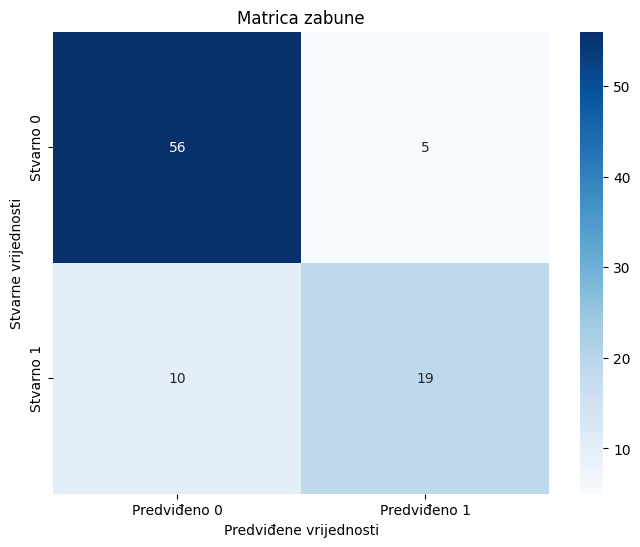

In [ ]:
# Izračunavanje matrice zabune
conf_matrix = confusion_matrix(Y_test, Y_pred)

# Pretvaranje matrice zabune u DataFrame za ljepši prikaz
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=['Predicted 0', 'Predicted 1'],
    columns=['Actual 0', 'Actual 1']
)
print("Confusion Matrix:")
print(conf_matrix_df)

# Grafički prikaz matrice zabune
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predviđeno 0', 'Predviđeno 1'],
            yticklabels=['Stvarno 0', 'Stvarno 1'])
plt.xlabel('Predviđene vrijednosti')
plt.ylabel('Stvarne vrijednosti')
plt.title('Matrica zabune')
plt.show()

In [ ]:
# Preciznost, odaziv, F-mjera
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.85      0.92      0.88        61
           1       0.79      0.66      0.72        29

    accuracy                           0.83        90
   macro avg       0.82      0.79      0.80        90
weighted avg       0.83      0.83      0.83        90



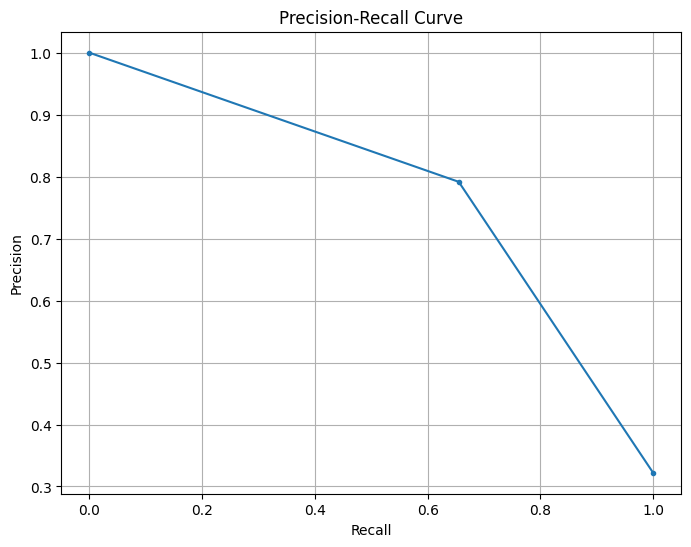

In [ ]:
# Calculate precision-recall curve
precision, recall, thresholds = precision_recall_curve(Y_test, Y_pred)

# Plot the precision-recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

Optimal Threshold: 0.28


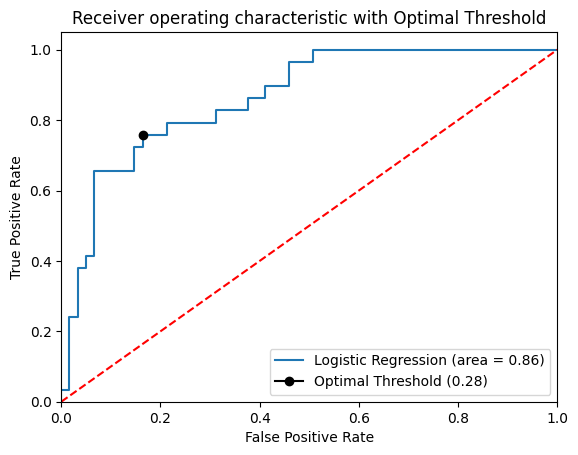

In [ ]:
# Calculate probabilities for the positive class
y_pred_proba = log_reg_model.predict_proba(X_test_scale)[:, 1]

# Calculate ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(Y_test, y_pred_proba)
logit_roc_auc = roc_auc_score(Y_test, y_pred_proba)

# Find the optimal threshold based on Youden's J statistic (tpr - fpr)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold: {optimal_threshold:.2f}")

# Plot the ROC curve with the optimal threshold marked
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.plot(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='black', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic with Optimal Threshold')
plt.legend(loc="lower right")
plt.show()